<a href="https://colab.research.google.com/github/snig-17/QM-GRUNGE/blob/main/crowding_and_popularity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

from google.colab import files
uploaded = files.upload()


filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.head()

Saving expeditions5.csv to expeditions5.csv


,Yr/Seas,Host,Nationalities,Leader(s),Route(s),Result,Smtrs,Dead,ExpedID,Year,...,hired_DR,mbr_DR,mbr_hired_ratio,total_DR,clean_routes,route_codes,result_clean,result_code,grp_success,success_rate
0,1990 Spr,China,"USA, China, USSR","Jim Whittaker, Vladimir Shataev, Lobsang Dawa",N Col-NE Ridge,Success,20.0,NaN,EVER-901-03,1990,...,0.0,0.0,0.0,0.0,n col-ne ridge,2,success,1,1,0.512820513
1,1990 Spr,Nepal,Australia,Timothy Macartney-Snape,Lho La-W Ridge (to 7400m) / S Col-SE Ridge,Success,1.0,NaN,EVER-901-06,1990,...,0.0,0.0,0.0,0.0,lho la-w ridge,6,success,1,1,0.25
2,1991 Spr,Nepal,USA,Peter Athans,S Col-SE Ridge,Success,1.0,NaN,EVER-911-01,1991,...,0.0,0.0,0.0,0.0,s col-se ridge,1,success,1,1,0.25
3,1991 Spr,Nepal,Nepal,Lobsang Tashi Sherpa,S Col-SE Ridge,Success,3.0,NaN,EVER-911-03,1991,...,0.0,0.0,0.0,0.0,s col-se ridge,1,success,1,1,0.230769231
4,1991 Spr,Nepal,"USA, Australia, Canada",Rick Wilcox,S Col-SE Ridge,Success,4.0,NaN,EVER-911-06,1991,...,0.0,0.0,0.0,0.0,s col-se ridge,1,success,1,1,0.4


In [ ]:
annual_summary = df.groupby('Year').agg(
    total_summitters=('Smtrs', 'sum'),
    expedition_count=('ExpedID', 'count')
).reset_index()

print("Annual Summary of Summitters and Expeditions:")
print(annual_summary.head())

Annual Summary of Summitters and Expeditions:
   Year  total_summitters  expedition_count
0  1990              72.0                22
1  1991              38.0                33
2  1992              90.0                33
3  1993             129.0                31
4  1994              51.0                26


In [ ]:
annual_summary['cumulative_summitters'] = annual_summary['total_summitters'].cumsum()

print("Annual Summary with Cumulative Summitters:")
print(annual_summary.head())

Annual Summary with Cumulative Summitters:
   Year  total_summitters  expedition_count  cumulative_summitters
0  1990              72.0                22                   72.0
1  1991              38.0                33                  110.0
2  1992              90.0                33                  200.0
3  1993             129.0                31                  329.0
4  1994              51.0                26                  380.0


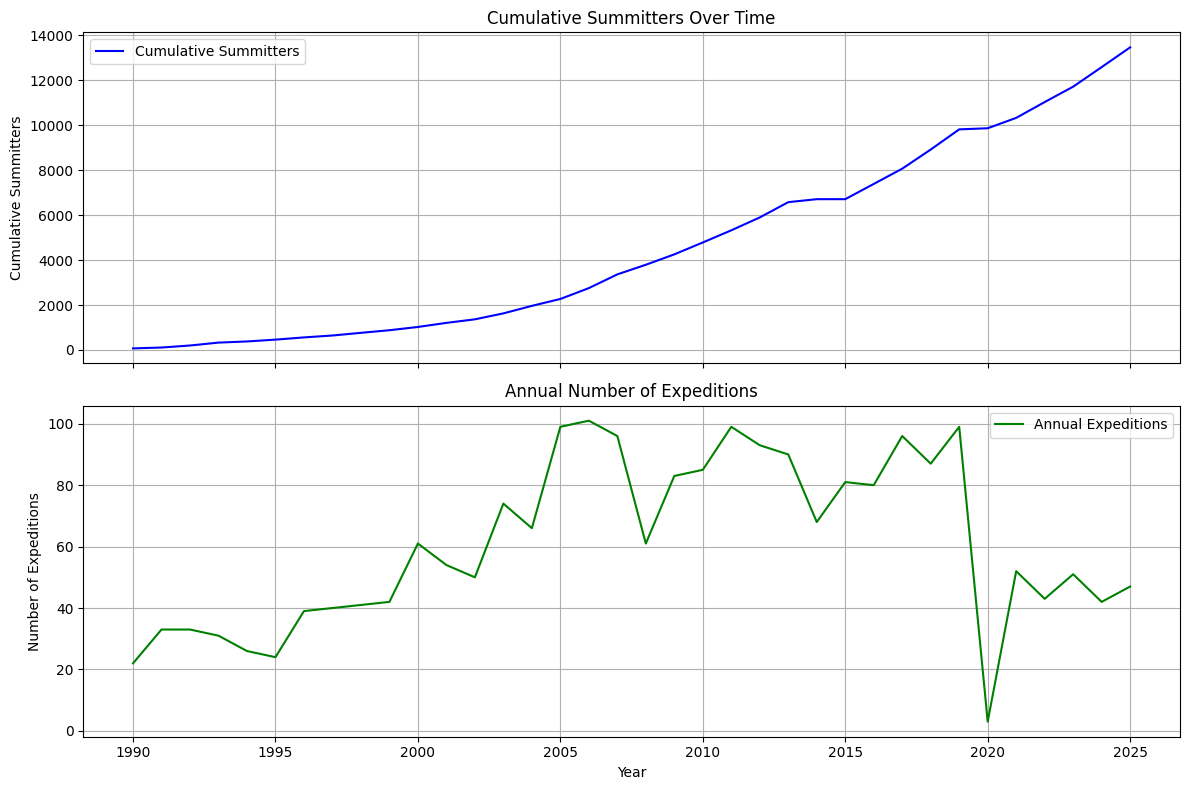

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

# Plot cumulative summitters
ax1.plot(annual_summary['Year'], annual_summary['cumulative_summitters'], color='blue', label='Cumulative Summitters')
ax1.set_title('Cumulative Summitters Over Time')
ax1.set_ylabel('Cumulative Summitters')
ax1.legend()
ax1.grid(True)

# Plot annual expedition count
ax2.plot(annual_summary['Year'], annual_summary['expedition_count'], color='green', label='Annual Expeditions')
ax2.set_title('Annual Number of Expeditions')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Expeditions')
ax2.legend()
ax2.grid(True)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Display the plots
plt.show()